In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import display, Math, Latex

from IPython.display import display, Math, Latex
import ipywidgets as widgets
from matplotlib.widgets import Slider, Button

from scipy.fft import fft, ifft
import scipy.special as sp
import scipy.optimize 

In [2]:
Delta = 0 #no detuning
kappa = 300e6*2*np.pi
gamma = kappa *0.1
drive = 0.2
theta = -np.pi/2
phi = 0
n_levels = 100
step = 30

In [3]:
# KFJPA parameters

EC = 48e5 * 2*np.pi#85e4 * 2*np.pi #2e6 * 2*np.pi
EL = 1650e9 * 2*np.pi#140e9 * 2*np.pi #70e9 * 2*np.pi
phi_zps = (2*EC/EL)**0.25 
STS_ratio = phi_zps**2/6 # |LAM/lam| ratio in abs value
print(STS_ratio)

0.0004020151261036849


In [4]:
def Gain_get_KFJPA(kappa,gamma,lam, ratio, drive, n_levels, theta, phi):
        
    a = qt.destroy(n_levels) 
    
    LAM = -ratio * lam
    
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag()*a.dag() + lam*np.exp(1j*theta)/2 * a * a
    H_alpha =  LAM * (a.dag()*a.dag()*a.dag()*a + a.dag() * a * a * a) 
   
    c_op_list = [np.sqrt(kappa+gamma) * a]

    epsilon = drive*kappa*np.exp(-1j*phi)
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j*np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    
    def Gain_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix
    g_KFJPA = Gain_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_KFJPA = 1/4 * np.abs(g_KFJPA[0,0] + g_KFJPA[1,1] + 1j*(g_KFJPA[1,0] - g_KFJPA[0,1]))**2

    return g_KFJPA,Gain_KFJPA

In [5]:
lam_range = np.linspace(0.0,1.94,step)*kappa/4

In [6]:
# lossless 
# KFJPA
g_KFJPA11=[]
g_KFJPA12=[]
g_KFJPA21=[]
g_KFJPA22=[]
Gain_KFJPA=[]

# lossy 
# KFJPA gamma 0.03 kappa
gl_KFJPA11=[]
gl_KFJPA12=[]
gl_KFJPA21=[]
gl_KFJPA22=[]
Gainl_KFJPA=[]

# lossy 
# KFJPA gamma 0.05 kappa
g2_KFJPA11=[]
g2_KFJPA12=[]
g2_KFJPA21=[]
g2_KFJPA22=[]
Gain2_KFJPA=[]

# lossy 
# KFJPA gamma 0.1 kappa
g3_KFJPA11=[]
g3_KFJPA12=[]
g3_KFJPA21=[]
g3_KFJPA22=[]
Gain3_KFJPA=[]

# lossy 
# KFJPA gamma 0.3 kappa
g4_KFJPA11=[]
g4_KFJPA12=[]
g4_KFJPA21=[]
g4_KFJPA22=[]
Gain4_KFJPA=[]

for lam in lam_range:
    
    v_Q,w_Q = Gain_get_KFJPA(kappa,0,lam, STS_ratio, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g_KFJPA11.append(v_Q[0,0])
    g_KFJPA12.append(v_Q[0,1])
    g_KFJPA21.append(v_Q[1,0])
    g_KFJPA22.append(v_Q[1,1])
    Gain_KFJPA.append(w_Q)
    
    vl_Q,wl_Q = Gain_get_KFJPA(kappa,0.03*kappa,lam,STS_ratio, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    gl_KFJPA11.append(vl_Q[0,0])
    gl_KFJPA12.append(vl_Q[0,1])
    gl_KFJPA21.append(vl_Q[1,0])
    gl_KFJPA22.append(vl_Q[1,1])
    Gainl_KFJPA.append(wl_Q)
    
    v2_Q,w2_Q = Gain_get_KFJPA(kappa,0.05*kappa,lam,STS_ratio, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g2_KFJPA11.append(v2_Q[0,0])
    g2_KFJPA12.append(v2_Q[0,1])
    g2_KFJPA21.append(v2_Q[1,0])
    g2_KFJPA22.append(v2_Q[1,1])
    Gain2_KFJPA.append(w2_Q)
    
    v3_Q,w3_Q = Gain_get_KFJPA(kappa,0.1*kappa,lam,STS_ratio, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g3_KFJPA11.append(v3_Q[0,0])
    g3_KFJPA12.append(v3_Q[0,1])
    g3_KFJPA21.append(v3_Q[1,0])
    g3_KFJPA22.append(v3_Q[1,1])
    Gain3_KFJPA.append(w3_Q)
    
    v4_Q,w4_Q = Gain_get_KFJPA(kappa,0.3*kappa,lam,STS_ratio, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g4_KFJPA11.append(v4_Q[0,0])
    g4_KFJPA12.append(v4_Q[0,1])
    g4_KFJPA21.append(v4_Q[1,0])
    g4_KFJPA22.append(v4_Q[1,1])
    Gain4_KFJPA.append(w4_Q)

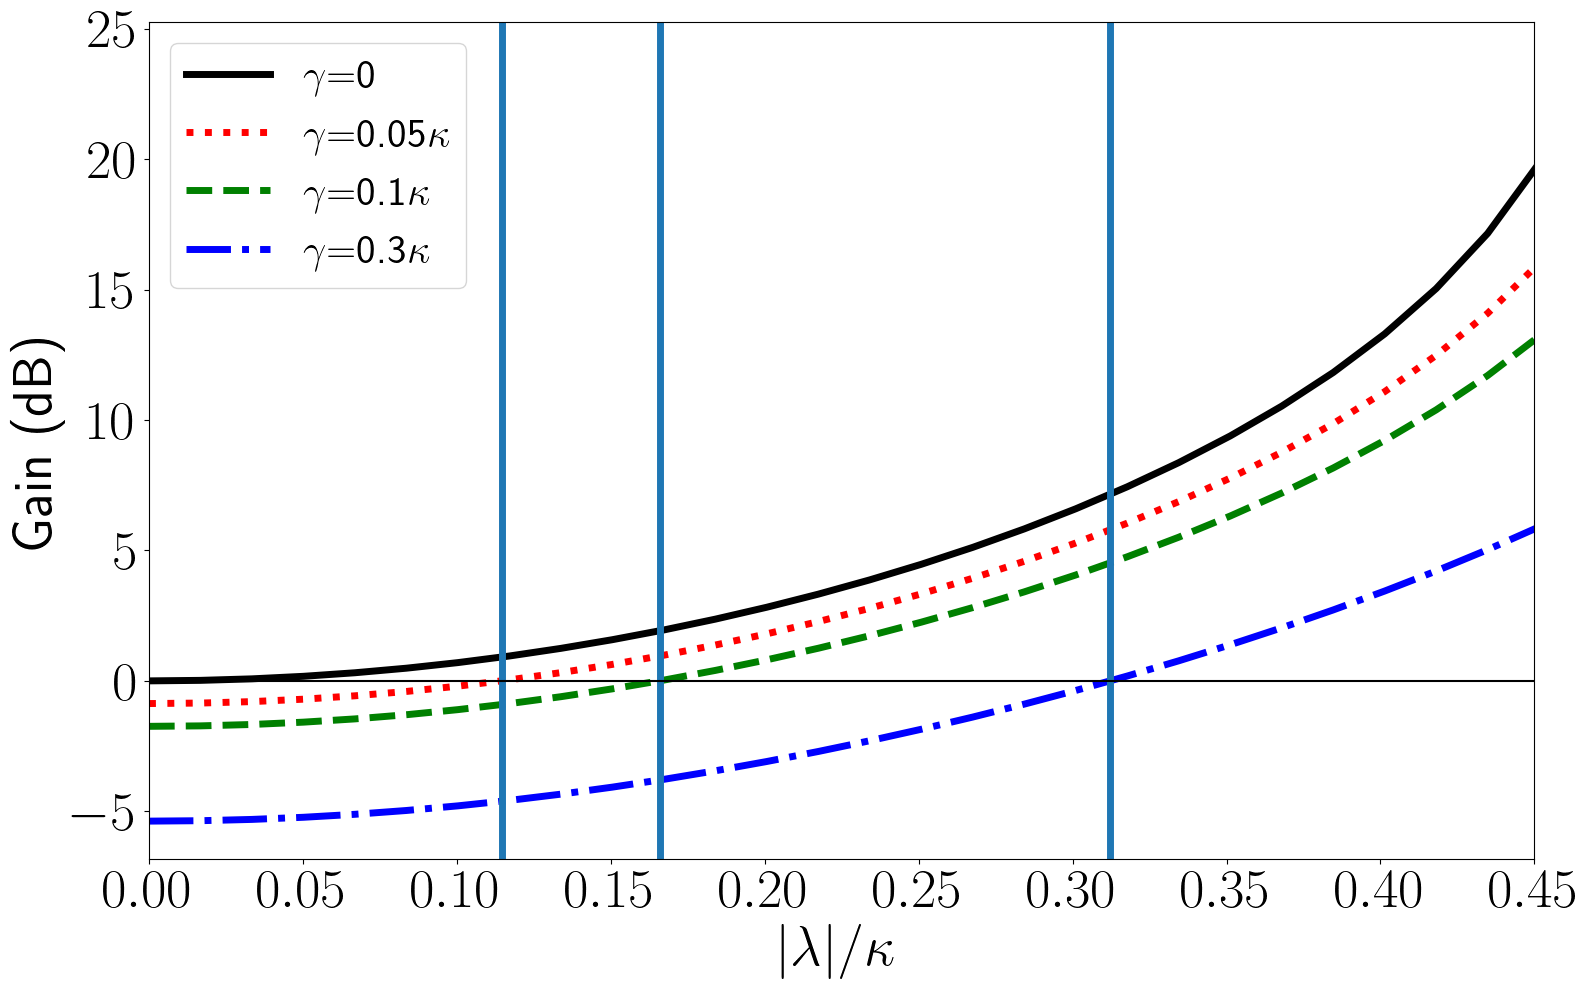

In [12]:
plt.figure(figsize=(16,10))
plt.rcParams['text.usetex'] = True
plt.plot(lam_range/kappa, 10*np.log10(Gain_KFJPA), c='black', linewidth=5, label = r'$\gamma$=0')
plt.plot(lam_range/kappa, 10*np.log10(Gain2_KFJPA), c='red', linestyle='dotted', linewidth=5, label = r'$\gamma$=0.05$\kappa$')
plt.plot(lam_range/kappa, 10*np.log10(Gain3_KFJPA), c='green', linestyle='dashed', linewidth=5, label = r'$\gamma$=0.1$\kappa$')
plt.plot(lam_range/kappa, 10*np.log10(Gain4_KFJPA), c='blue', linestyle='-.', linewidth=5, label = r'$\gamma$=0.3$\kappa$')

gamma1 = 0.1 * kappa
gamma2 = 0.05*kappa
gamma3 = 0.03*kappa
gamma4 = 0.3*kappa
plt.axvline(x=(0.5*np.sqrt((kappa+gamma1)*gamma1)/kappa),linewidth=5)
plt.axvline(x=(0.5*np.sqrt((kappa+gamma2)*gamma2)/kappa),linewidth=5)
plt.axvline(x=(0.5*np.sqrt((kappa+gamma4)*gamma4)/kappa),linewidth=5)
#plt.axvline(x=0.5*np.sqrt((kappa+gamma3)*gamma3))
thresh = [0 for i in enumerate(lam_range/kappa)]
plt.plot(lam_range/kappa, thresh, c='black')

plt.gca().xaxis.get_offset_text().set_size(30)


plt.legend(loc='upper left', fontsize=30)
plt.xlabel(r'$|\lambda|/\kappa$',fontsize=40)
plt.ylabel(r'Gain (dB)',fontsize=40)
#plt.ylim(-6,28)
#plt.xlim(0,lam_range.max()/kappa)
plt.xlim(0, 0.45)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.tight_layout()
plt.savefig("Deamp drivesies final for paper.jpeg")

In [8]:
def Gain_get_lossy_DPA(kappa, gamma, lam, drive, n_levels, theta, phi):
    
    a = qt.destroy(n_levels)
        
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag() * a.dag() + np.conj(lam*np.exp(-1j*theta))/2 * a * a
    
    c_op_list = [np.sqrt(kappa+gamma) * a]
    epsilon = drive*kappa*np.exp(-1j*phi) #probe strength
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j * np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    def Gain_DPA_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix
    kg = kappa + gamma
    g_DPA = Gain_DPA_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_DPA = 1/4 * np.abs(g_DPA[0,0] + g_DPA[1,1] + 1j*(g_DPA[1,0] - g_DPA[0,1]))**2
    Gain_DPA_analytical = np.abs(((kappa*kg/2-1j*kappa*Delta) / (Delta**2+(kg/2)**2-lam**2))-1)**2 #assumed w=0 here (ws-wp/2)
        
    return g_DPA,Gain_DPA,Gain_DPA_analytical

In [9]:
# lossless DPA
g_DPA11=np.zeros(step, dtype=np.complex128)
g_DPA12=np.zeros(step, dtype=np.complex128)
g_DPA21=np.zeros(step, dtype=np.complex128)
g_DPA22=np.zeros(step, dtype=np.complex128)
Gain_DPA=np.zeros(step, dtype=np.complex128)

In [10]:
i = 0

for lam in np.linspace(0.0,1.94,step)*kappa/4:
    c_Q,d_Q,e_Q = Gain_get_lossy_DPA(kappa, 0,lam, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g_DPA11[i]=c_Q[0,0]
    g_DPA12[i]=c_Q[0,1]
    g_DPA21[i]=c_Q[1,0]
    g_DPA22[i]=c_Q[1,1]
    Gain_DPA[i]=d_Q
    i+=1

C:\Users\kagan\anaconda3\envs\kerrcat\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\kagan\anaconda3\envs\kerrcat\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


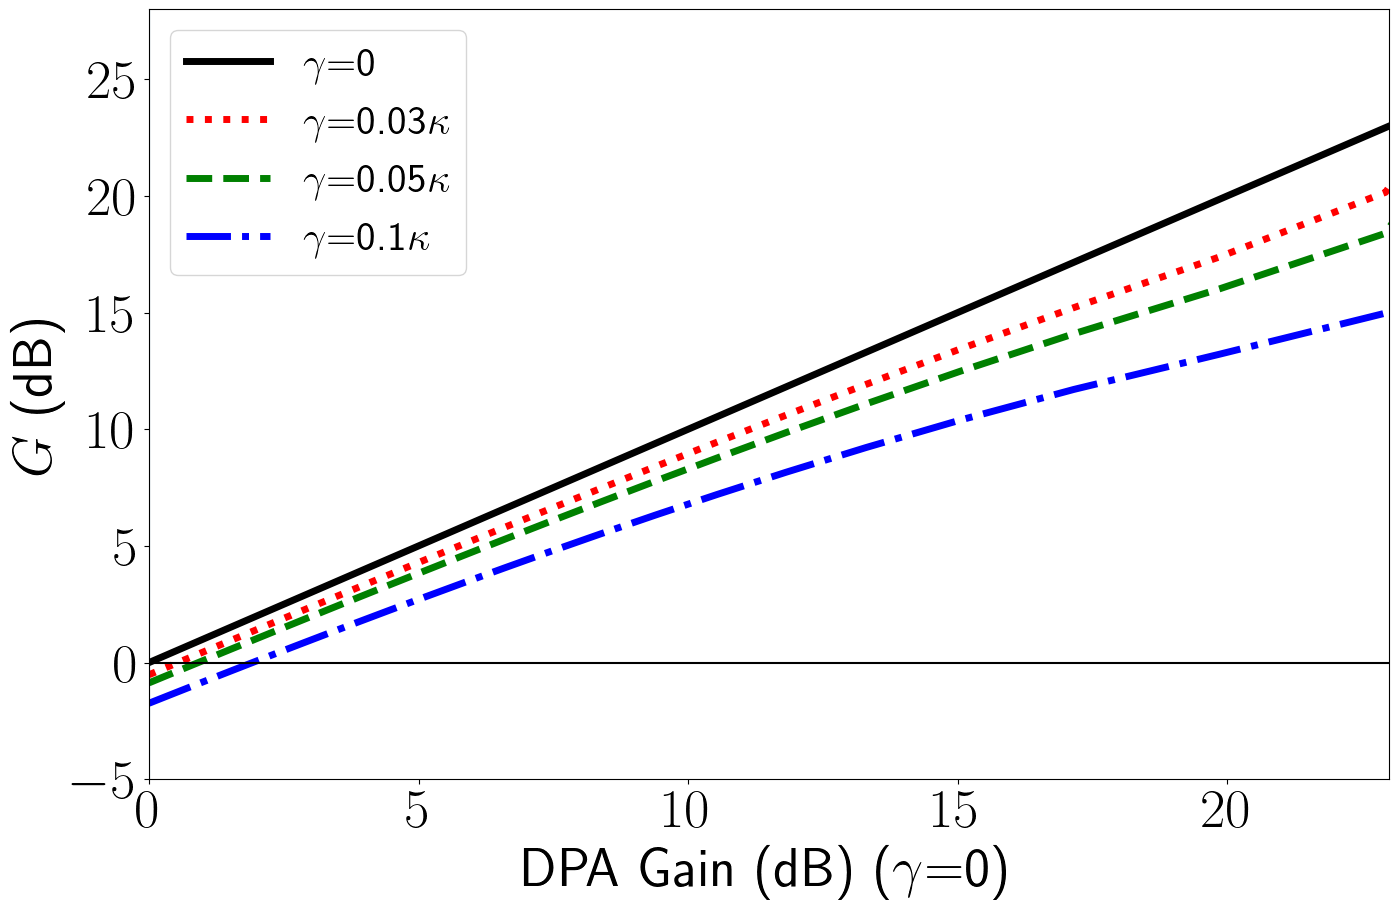

In [15]:
plt.figure(figsize=(16,10))
plt.rcParams['text.usetex'] = True
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_KFJPA), c='black', linewidth=5, label = r'$\gamma$=0')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainl_KFJPA), c='red', linestyle='dotted', linewidth=5, label = r'$\gamma$=0.03$\kappa$')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain2_KFJPA), c='green', linestyle='dashed', linewidth=5, label = r'$\gamma$=0.05$\kappa$')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain3_KFJPA), c='blue', linestyle='-.', linewidth=5, label = r'$\gamma$=0.1$\kappa$')

plt.axvline(x=0)
thresh = [0 for i in enumerate(10*np.log10(Gain_DPA))]
plt.plot(lam_range, thresh, c='black')

plt.legend(loc='upper left', fontsize=30)
plt.xlabel(r'DPA Gain (dB) ($\gamma$=0)',fontsize=40)
plt.ylabel(r'$G$ (dB)',fontsize=40)
plt.xlim(0,23)
plt.ylim(-5,28)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.savefig("Extra noise final.jpeg")